'\ndf = df.dropna(subset="salary_year_avg")\ndf_exploded = df.explode("job_skills")\ntop_requested = df_exploded.groupby("job_skills")["salary_year_avg"].size().sort_values(ascending=False).head(10).index.tolist()\ndf_mostrequested= df_exploded[df_exploded["job_skills"].isin(top_requested)]\npivot_req = df_mostrequested.groupby("job_skills")["salary_year_avg"].median().sort_values(ascending=True)\npivot_req.plot(kind="barh")\n\n'

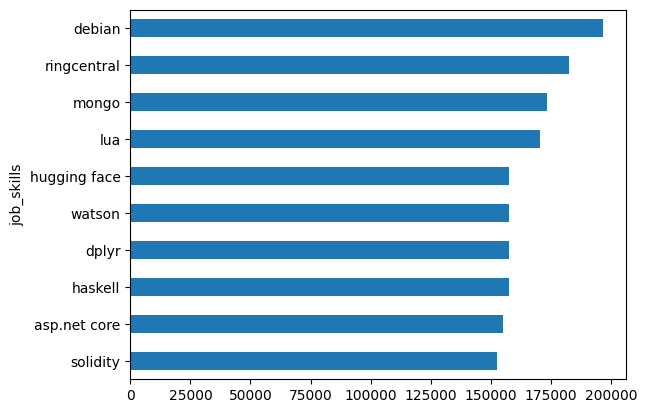

In [29]:
import numpy as np
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset


dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])
df["job_skills"] = df["job_skills"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)


#______________________________________SALARIO PARA LAS SKILLS MEJOR PAGADAS


df = df.dropna(subset="salary_year_avg")
df_exploded = df.explode("job_skills")
top_paid = df_exploded.groupby("job_skills")["salary_year_avg"].median().sort_values(ascending=False).head(10).index.tolist()
df_mostpaid= df_exploded[df_exploded["job_skills"].isin(top_paid)]
pivot_paid = df_mostpaid.groupby("job_skills")["salary_year_avg"].median().sort_values(ascending=True)
pivot_paid.plot(kind="barh")



#______________________________________SALARIO PARA LAS SKILLS MÁS DEMANDADAS

"""
df = df.dropna(subset="salary_year_avg")
df_exploded = df.explode("job_skills")
top_requested = df_exploded.groupby("job_skills")["salary_year_avg"].size().sort_values(ascending=False).head(10).index.tolist()
df_mostrequested= df_exploded[df_exploded["job_skills"].isin(top_requested)]
pivot_req = df_mostrequested.groupby("job_skills")["salary_year_avg"].median().sort_values(ascending=True)
pivot_req.plot(kind="barh")

"""

